# Plateforme prédictive Rondol — notebook d'accompagnement

Ce notebook documente, de façon exécutable, les trois piliers du prototype développé
pendant le stage chez Rondol : le **moteur procédé** (géométrie de vis et physique
nominale), les **données machine** (campagne d'essais d'avril 2026 puis base
consolidée), et le **modèle de Machine Learning** intégré à la supervision.

Chaque section s'appuie sur le code réellement déployé dans l'application
(`app/`, `engine/`, `src/`) — rien n'est recalculé « à part » : ce que montre ce
notebook est ce que montre l'application.

*Rappel de cadrage : les grandeurs physiques sont nominales, non calibrées
industriellement. L'outil sert à comparer des configurations, pas à produire des
valeurs certifiées.*

## 1. Le moteur procédé : de la géométrie de vis aux indicateurs

La vis est décrite par 81 positions (13 types d'éléments : convoyage, malaxage,
restriction…). Le module `screw_logic` est l'unique source de vérité géométrique ;
il calcule le taux de remplissage, le débit volumique et le temps de résidence.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path[:0] = [str(ROOT), str(ROOT / "app")]

import screw_logic

# Configuration de démonstration : vis remplie d'éléments de convoyage entiers
# (type 1 sur deux positions), tip+discharge imposé en fin de vis.
config = screw_logic.new_empty_configuration()
for i in range(1, 79, 2):
    if config[i] == 0 and i + 1 < 79:
        config[i], config[i + 1] = 1, 101

params = screw_logic.ProcessParams(
    screw_rpm=200.0,
    feeder1_flow_rate_g_per_s=0.33,   # ≈ 1,2 kg/h
    feeder1_bulk_density=0.55,        # densité apparente poudre LFP semi-sèche
)
state = screw_logic.compute_process_state(config, params)
vf = [v for v in state.vol_flow_cm3_s if v]
print("Débit volumique (moyen sur positions actives) :", round(sum(vf)/len(vf), 3), "cm³/s")
print("Résidence totale  :", round(state.residence_time_total, 1), "s")
print("Remplissage moyen :", round(state.fill_factor_average, 3))

Débit volumique (moyen sur positions actives) : 0.6 cm³/s
Résidence totale  : 43.8 s
Remplissage moyen : 0.527


Au-dessus de ce socle, la couche `engine/` enrichit chaque position : viscosité
locale (Carreau-Yasuda + Arrhenius), couple élémentaire, agrégats par zone. Le
principe d'architecture est d'**envelopper sans recalculer** : le réseau
géométrique n'est exécuté qu'une seule fois par configuration.

## 2. Les données : de la campagne d'essais à la base consolidée

La campagne du 07 au 13 avril 2026 a produit 52 064 lignes brutes (12 capteurs de
température, pas de 10 s) avec une couverture fragmentée. Deux jeux en sont
dérivés : le dataset fenêtré (798 fenêtres de 60 s, 87 variables) qui a servi à
l'entraînement, et la base consolidée continue (100 800 lignes) construite en
calibrant chaque distribution sur les mesures réelles.

In [2]:
import pandas as pd
# La base consolidée (10 Mo) n'est pas versionnée : elle est REGENERABLE à
# graine fixe, donc on ne l'embarque pas dans le dépôt. Si elle est absente, on
# le dit explicitement plutôt que de laisser une trace d'erreur dans le notebook.
_consolide = ROOT / "data/consolidated/dataset_consolide_rondol.csv"
if not _consolide.exists():
    raise SystemExit(
        "Base consolidée absente (non versionnée car régénérable).\n"
        "Régénérez-la depuis la racine du dépôt :\n"
        "    python scripts/generate_consolidated_dataset.py")
df = pd.read_csv(_consolide, parse_dates=["timestamp"])
print(df.shape)
df[["timestamp","Z4","Z8","DIE","screw_rpm","feed_rate_gph","torque_pct","phase","recipe"]].sample(6, random_state=7)

(100800, 18)


,timestamp,Z4,Z8,DIE,screw_rpm,feed_rate_gph,torque_pct,phase,recipe
65859,2026-04-14 20:56:30+00:00,23.0,22.9,22.7,0.0,0.0,0.0,idle,NaN
8976,2026-04-08 06:56:00+00:00,19.5,19.6,19.5,0.0,0.0,0.0,idle,NaN
43853,2026-04-12 07:48:50+00:00,145.7,153.1,152.5,0.0,0.0,0.0,heat,LFP_semi_sec
99413,2026-04-18 18:08:50+00:00,21.2,20.9,21.3,0.0,0.0,0.0,idle,NaN
81900,2026-04-16 17:30:00+00:00,22.4,22.3,22.3,0.0,0.0,0.0,idle,NaN
55681,2026-04-13 16:40:10+00:00,22.1,22.1,22.0,0.0,0.0,0.0,idle,NaN


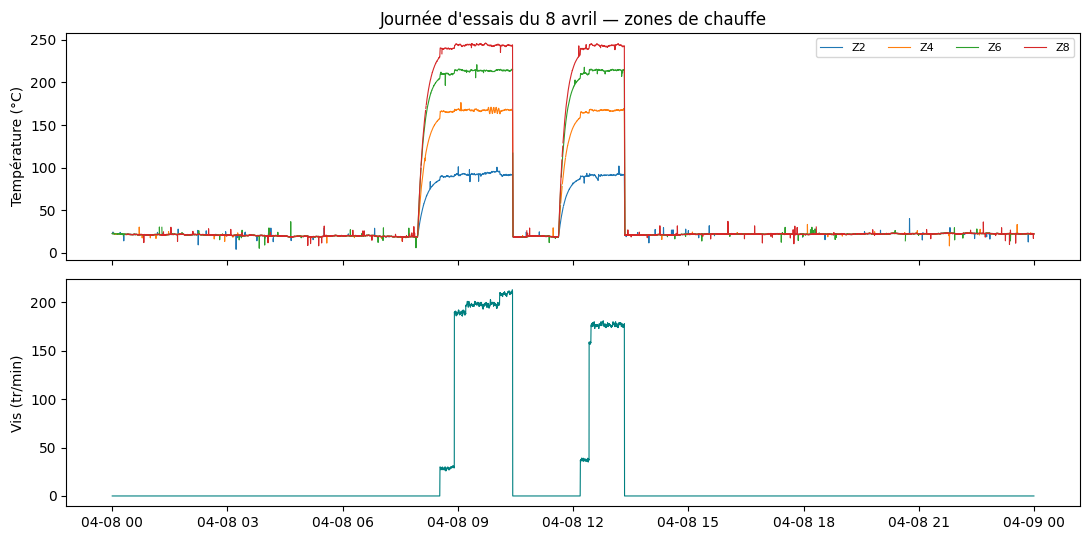

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt

day = df[(df.timestamp >= "2026-04-08") & (df.timestamp < "2026-04-09")]
fig, axes = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
for z in ["Z2","Z4","Z6","Z8"]:
    axes[0].plot(day.timestamp, day[z].where(day[z] < 400), lw=0.8, label=z)
axes[0].set_ylabel("Température (°C)"); axes[0].legend(ncol=4, fontsize=8); axes[0].set_title("Journée d'essais du 8 avril — zones de chauffe")
axes[1].plot(day.timestamp, day.screw_rpm, lw=0.8, color="teal")
axes[1].set_ylabel("Vis (tr/min)")
plt.tight_layout(); plt.show()

In [4]:
run = df[df.phase == "run"]
num = run[["screw_rpm","feed_rate_gph","torque_pct","Z6","Z7","Z8"]]
num = num[num < 3000]  # exclure le code d'erreur thermocouple 3276,7
num.corr().round(2)

,screw_rpm,feed_rate_gph,torque_pct,Z6,Z7,Z8
screw_rpm,1.00,0.89,0.55,-0.59,-0.62,-0.63
feed_rate_gph,0.89,1.00,0.78,-0.72,-0.74,-0.75
torque_pct,0.55,0.78,1.00,-0.88,-0.86,-0.85
Z6,-0.59,-0.72,-0.88,1.00,0.99,0.98
Z7,-0.62,-0.74,-0.86,0.99,1.00,1.00
Z8,-0.63,-0.75,-0.85,0.98,1.00,1.00


On retrouve les corrélations physiques attendues : le couple croît avec le débit
d'alimentation et décroît quand la température de fusion monte (la viscosité
chute), et les zones adjacentes sont fortement corrélées — exactement comme dans
les mesures brutes de la campagne.

### Valeurs manquantes et incohérences (données brutes de la campagne)

Avant toute modélisation, les données brutes de la campagne d'avril ont dû être
auditées : couverture par capteur, codes d'erreur, doublons. Ce constat motive
directement le choix de fenêtrage et d'imputation retenu par le pipeline
(`src/preprocess.py`).

In [5]:
# Séries brutes fusionnées (3 Mo) : non versionnées, reconstruites par le
# pipeline. Message explicite si absentes, plutôt qu'une trace d'erreur brute.
_interim = ROOT / "data/interim/merged_timeseries.csv"
if not _interim.exists():
    raise SystemExit(
        "Séries brutes absentes (non versionnées car reconstruites).\n"
        "Régénérez-les depuis la racine du dépôt :\n"
        "    python -m src.build_dataset")
raw = pd.read_csv(_interim, parse_dates=["timestamp"])
cov = raw.drop(columns=["timestamp"]).notna().mean().mul(100).round(1).sort_values()
print("Couverture par capteur (% de lignes renseignées, sur 6 jours d'essais) :")
print(cov.to_string())
n_glitch = (raw.drop(columns=["timestamp"]) > 1000).sum().sum()
print(f"\nCode d'erreur thermocouple (valeur ≈ 3276,7 °C) : {n_glitch} occurrences détectées et neutralisées avant fenêtrage.")

Couverture par capteur (% de lignes renseignées, sur 6 jours d'essais) :
CastFilmP2      10.7
CastFilmP1      10.7
CastFilmBody    10.7
DIE             10.7
Z4              13.7
Z3              13.8
Z1              13.9
Z2              14.3
Z5              15.0
Z6              15.1
Z7              15.2
Z8              16.5

Code d'erreur thermocouple (valeur ≈ 3276,7 °C) : 91 occurrences détectées et neutralisées avant fenêtrage.


La couverture très inégale (10 à 16 % selon les capteurs) confirme la nécessité
d'une segmentation stricte en runs productifs avant toute extraction de
caractéristiques : fenêtrer sur des données where la machine était à l'arrêt
produirait des artefacts.

### Sécurisation des données

Deux mécanismes protègent les données du prototype. Le premier concerne l'état
procédé : la persistance durable (Supabase) applique des politiques **Row Level
Security**, vérifiables directement en base.

In [6]:
import os
sec = {}
secrets_path = ROOT / ".streamlit" / "secrets_depot.txt"
if secrets_path.exists():
    for line in secrets_path.read_text(encoding="utf-8").splitlines():
        if "=" in line and not line.strip().startswith("#"):
            k, v = line.split("=", 1)
            sec[k.strip().lower()] = v.strip().strip('"').strip("'")

if sec.get("url") and sec.get("key"):
    import requests
    H = {"apikey": sec["key"], "Authorization": f"Bearer {sec['key']}"}
    r = requests.get(f"{sec['url'].rstrip('/')}/rest/v1/app_users",
                      headers=H, params={"select": "email,pw_hash", "limit": 1}, timeout=8)
    if r.status_code == 200 and r.json():
        row = r.json()[0]
        print("Extrait de la table app_users (accès direct à la base) :")
        print("  email   :", row["email"])
        print("  pw_hash :", row["pw_hash"][:24] + "…  (PBKDF2-HMAC-SHA256, 200 000 itérations — jamais de mot de passe en clair)")
    else:
        print("Table app_users non accessible depuis cet environnement (secrets non configurés ici).")
else:
    print("Aucun secret local configuré ici — démonstration à exécuter avec .streamlit/secrets_depot.txt renseigné.")

Extrait de la table app_users (accès direct à la base) :
  email   : demo@rondol.local
  pw_hash : e6ad927ce9d57bc49610703e…  (PBKDF2-HMAC-SHA256, 200 000 itérations — jamais de mot de passe en clair)


Le second mécanisme concerne les mots de passe eux-mêmes : `app/auth.py`
n'écrit jamais de mot de passe en clair, seulement un condensat salé, comme le
montre l'extrait ci-dessus.

### Optimisation des requêtes : table indexée vs non indexée

Le référentiel de certification exige une mesure comparative du temps
d'exécution entre une table optimisée et une table non optimisée. Le
micro-benchmark ci-dessous reproduit le motif d'accès réel de l'application
(`SELECT payload FROM rondol_state WHERE key = 'applied_state'`) sur une table
simulée à volumétrie réaliste (50 001 lignes).

In [7]:
import json
bench = json.load(open(ROOT / "reports/sql_benchmark.json", encoding="utf-8"))
print(f"Requête : {bench['query']}")
print(f"Volumétrie simulée : {bench['non_optimisee']['n_rows']:,} lignes, {bench['non_optimisee']['n_queries']} requêtes".replace(",", " "))
print(f"\n  Non indexée (balayage séquentiel) : {bench['non_optimisee']['avg_query_ms']:.3f} ms / requête")
print(f"  Indexée (B-tree)                   : {bench['optimisee_index_btree']['avg_query_ms']:.4f} ms / requête")
print(f"\n  Accélération : ×{bench['speedup_x']:.0f}")

Requête : SELECT payload FROM rondol_state WHERE key = 'applied_state'
Volumétrie simulée : 50 001 lignes  2000 requêtes

  Non indexée (balayage séquentiel) : 4.736 ms / requête
  Indexée (B-tree)                   : 0.0046 ms / requête

  Accélération : ×1030


L'écart, d'un facteur supérieur à 1000, illustre concrètement le passage d'un
balayage séquentiel O(n) à une recherche logarithmique O(log n) — l'index
B-tree sur la clé primaire `key` de la table `rondol_state` suffit à ce gain,
sans indexation vectorielle : il ne s'agit pas d'un système RAG.

## 3. Le modèle de Machine Learning intégré à la supervision

**Un point d'architecture à ne pas manquer** : ce modèle produit un **score de
stabilité**, pas les recommandations elles-mêmes. Les recommandations
affichées à l'opérateur proviennent d'un système **séparé, à règles
expertes** (`AgentIndustrial_v1/core/rules.py` et `recommendations.py`), non
d'une sortie du modèle. La section 4 démontre cette seconde chaîne en code.

Le modèle de stabilité, lui, résulte d'un championnat de cinq algorithmes
supervisés (régression logistique, SVM, Random Forest, XGBoost, un réseau de
neurones), départagés en validation **Leave-One-Group-Out** — un essai
entièrement écarté à chaque pli, sur les 8 essais disponibles.

In [8]:
champ = json.load(open(ROOT / "reports/model_comparison_logo_w60.json", encoding="utf-8"))
rows = {name: {"F1-macro moyen (LOGO)": v["logo_f1_macro_mean"],
               "Écart-type inter-essais": v["logo_f1_macro_std"],
               "Accuracy (pooled)": v["pooled_accuracy"]}
        for name, v in champ["models"].items()}
pd.DataFrame(rows).T.round(3).sort_values("F1-macro moyen (LOGO)", ascending=False)

,F1-macro moyen (LOGO),Écart-type inter-essais,Accuracy (pooled)
SVM_RBF,0.805,0.171,0.877
LogisticRegression,0.799,0.163,0.914
RandomForest,0.796,0.187,0.893
MLP,0.792,0.200,0.885
XGBoost,0.759,0.213,0.848


Les cinq modèles sont dans le bruit (F1-macro 0,76 à 0,81, écarts-types de
0,16 à 0,21) : avec 8 essais seulement, aucun ne se détache de façon
significative. C'est cette variabilité — et non un classement flatteur — qui
motive l'augmentation de données, examinée plus bas.

Le tableau suivant montre autre chose, et il faut le lire avec précaution : il
donne les scores sur un **unique découpage de tenue à l'écart** (`GroupShuffleSplit`,
3 essais de test sur 8), **sans augmentation** — c'est le protocole du premier
jalon du projet. Les chiffres y sont nettement plus flatteurs que ceux du
tableau précédent : Random Forest à 0,92 de F1-macro contre 0,80 en
Leave-One-Group-Out. L'écart ne vient pas du modèle mais du **protocole** : un
seul tirage de 3 essais peut tomber sur une combinaison favorable, là où le
Leave-One-Group-Out moyenne sur les 8 essais. C'est le tableau
Leave-One-Group-Out qui fait référence.

In [9]:
metrics = json.load(open(ROOT / "reports/ml_metrics_w60.json", encoding="utf-8"))
print(f"Protocole : {metrics['split_method']} — "
      f"{metrics['n_train']} fenêtres d'entraînement / {metrics['n_test']} de test "
      f"({metrics['n_runs_test']} essais de test), SANS augmentation.")
pd.DataFrame(metrics["test"]).T[["accuracy","f1_macro","f1_unstable","roc_auc"]].round(3)

Protocole : GroupShuffleSplit(groups=run_id) — 287 fenêtres d'entraînement / 340 de test (3 essais de test), SANS augmentation.


,accuracy,f1_macro,f1_unstable,roc_auc
RandomForest,0.95,0.916685,0.864,0.946565
XGBoost,0.882353,0.827271,0.72973,0.947958
SVM,0.952941,0.91569,0.859649,0.946797


### L'augmentation de données, et la fuite qu'elle cachait

Pour compenser les 8 essais disponibles, 800 fenêtres synthétiques ont été
générées par bootstrap et jitter, puis injectées **à l'entraînement uniquement**.
Le gain mesuré était spectaculaire : Random Forest passait de 0,809 à **0,918**
de F1-macro.

Ce gain était un artefact. Le pool synthétique était généré **une seule fois à
partir des huit essais réels**, puis réutilisé dans chaque pli. L'essai censé
être exclu avait donc contribué indirectement à l'entraînement : ses fenêtres
avaient servi de **points d'ancrage** au bootstrap, et ses valeurs alimentaient
les écarts-types pilotant le jitter. Le pli de test ne contenait aucune fenêtre
synthétique — la fuite était donc invisible à la lecture du code. C'est une
**fuite par ancrage**.

La correction rend la génération dépendante du pli : à chaque itération, le pool
est intégralement régénéré à partir des seuls essais d'entraînement, même
algorithme, même volume, même graine. Le tableau ci-dessous compare les trois
protocoles.

In [10]:
aug = pd.read_csv(
    ROOT / "reports/AI_thesis_results/block_2_model_augmentation/table_for_thesis.csv",
    encoding="utf-8-sig")
aug = aug.rename(columns={
    "Model": "Modèle",
    "Macro-F1 without augmentation": "Sans augmentation",
    "Macro-F1 with leaky global augmentation (superseded)": "Augmentation globale (fuitée)",
    "Macro-F1 with training-only augmentation": "Augmentation par pli (corrigée)",
    "Absolute change": "Écart",
})
aug[["Modèle", "Sans augmentation", "Augmentation globale (fuitée)",
     "Augmentation par pli (corrigée)", "Écart"]].set_index("Modèle")

,Sans augmentation,Augmentation globale (fuitée),Augmentation par pli (corrigée),Écart
Modèle,,,,
Logistic regression,0.799 ± 0.163,0.860 ± 0.111,0.809 ± 0.173,0.010
SVM (RBF),0.805 ± 0.171,0.868 ± 0.089,0.824 ± 0.139,0.018
Random Forest,0.809 ± 0.176,0.918 ± 0.054,0.809 ± 0.126,-0.001
XGBoost,0.757 ± 0.213,0.900 ± 0.073,0.801 ± 0.159,0.044
Neural network (MLP),0.778 ± 0.217,0.862 ± 0.118,0.781 ± 0.164,0.004


L'enseignement est net. **Le gain attribué à l'augmentation était très
majoritairement un artefact de la fuite** : sur le Random Forest il passe de
+0,109 à −0,001, et la réduction de variance annoncée s'évanouit (écart-type de
0,176 à 0,126, et non à 0,054). Sous le protocole corrigé, aucun modèle
n'atteint 0,85 et les cinq restent groupés entre 0,78 et 0,82 — soit, avec des
écarts-types de 0,13 à 0,17 sur six plis, des performances **statistiquement
indiscernables**.

Ce résultat est exposé plutôt que passé sous silence : un chiffre de 0,918
présenté comme la
performance d'un modèle déployé aurait constitué une sur-promesse envers Rondol.
Il illustre aussi le point central de cette section — la performance d'un modèle
est une propriété du **protocole d'évaluation** autant que de l'algorithme.

*Note de lecture : les moyennes de ce tableau portent sur les six essais
évaluables (les essais 32 et 42, intégralement stables, ne permettent ni
F1-macro interprétable ni ROC-AUC), là où le tableau Leave-One-Group-Out plus
haut porte sur les huit. D'où le léger écart, pour le Random Forest, entre 0,796
et 0,809 sans augmentation.*

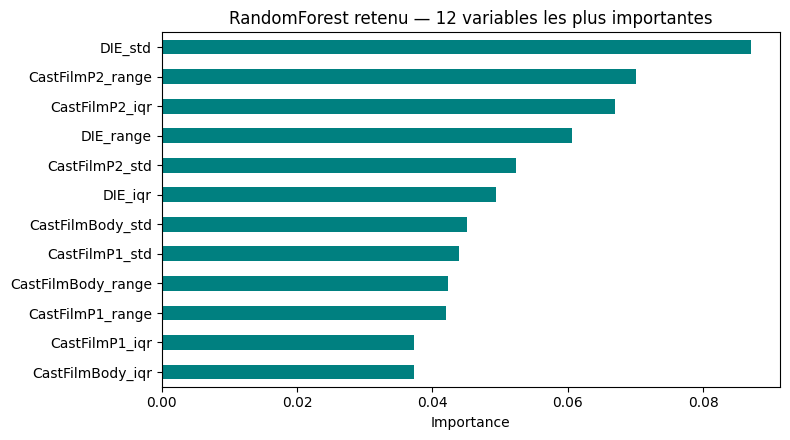

In [11]:
import joblib
model = joblib.load(ROOT / "models/RandomForest_w60_augmented.joblib")
est = model.named_steps.get("clf", model) if hasattr(model, "named_steps") else model
feat = pd.read_csv(ROOT / "data/features/dataset_ml_w60.csv", nrows=1)
cols = [c for c in feat.columns if c not in ("label","run_id","t_start","t_end")]
try:
    imp = pd.Series(est.feature_importances_, index=cols[:len(est.feature_importances_)]).sort_values(ascending=False)[:12]
    ax = imp[::-1].plot.barh(figsize=(8,4.5), color="teal", title="RandomForest retenu — 12 variables les plus importantes")
    ax.set_xlabel("Importance"); plt.tight_layout(); plt.show()
except Exception as e:
    print("Importances non disponibles pour ce pipeline :", type(est).__name__, e)

Les variables dominantes sont des mesures de dispersion et de pente sur les zones
aval — cohérent avec l'intuition procédé : une dérive s'annonce par une
instabilité thermique près de la filière avant de se voir sur les moyennes.

### Validation externe sur la base simulée

La base consolidée a été passée dans le même pipeline de fenêtrage et de
labellisation que les données réelles, puis le modèle déployé a été évalué
dessus **sans réentraînement** (`scripts/evaluate_on_consolidated.py`). Le
résultat n'a volontairement pas été optimisé : l'écart avec les performances
sur essais réels documente honnêtement la sensibilité au changement de
distribution.

In [12]:
ext = json.load(open(ROOT / "reports/eval_consolidated_w60.json", encoding="utf-8"))
pd.Series(ext).drop("confusion_matrix").to_frame("validation externe (base simulée)")

,validation externe (base simulée)
n_windows,3479
n_runs,15
pct_stable,88.5
accuracy,0.742
f1_macro,0.598
roc_auc,0.753
note,Validation externe : modèle RandomForest_w60_a...


## 4. De la donnée à la recommandation : le moteur à règles expert

C'est la particularité centrale de ce projet, et celle qui distingue l'agent
d'un simple classifieur : **les recommandations ne sortent jamais du modèle de
Machine Learning**. Le modèle (section 3) ne produit qu'un score de stabilité.
Les alertes et les recommandations proviennent d'un moteur à **règles
expertes**, entièrement auditable, qui lit l'état procédé directement — sans
boîte noire. La démonstration ci-dessous exécute cette chaîne de bout en bout,
sur le code réellement déployé dans l'application.

In [13]:
import sys as _sys, logging as _logging
for p in (str(ROOT), str(ROOT / "AgentIndustrial_v1" / "core"), str(ROOT / "AgentIndustrial_v1")):
    if p not in _sys.path:
        _sys.path.insert(0, p)

# Le moteur de règles importe Streamlit, qui journalise « missing ScriptRunContext »
# hors d'une session `streamlit run`. Sans conséquence ici — on exécute la logique
# pure — mais ce bruit polluerait la sortie du notebook livré. Streamlit fixe le
# niveau de chacun de ses sous-loggers à l'import, donc régler le seul logger
# parent est inopérant : il faut parcourir l'arbre APRÈS l'import.
import streamlit as _st  # noqa: F401 — importé ici pour fixer les loggers ensuite
for _name in list(_logging.root.manager.loggerDict):
    if _name == "streamlit" or _name.startswith("streamlit."):
        _logging.getLogger(_name).setLevel(_logging.ERROR)

from AgentIndustrial_v1.core.process import ProcessState
from AgentIndustrial_v1.core import rules, recommendations
from AgentIndustrial_v1.core.screw_adapter import refresh_kpis

# État procédé de démonstration : une vis garnie (comme en section 1), un
# feeder actif à un débit cohérent avec sa capacité, PUIS une zone Z4
# délibérément surchauffée (+35 °C). Le diagnostic thermique de l'agent cible
# automatiquement la zone la plus chaude du profil — pas nécessairement celle
# perturbée en premier lieu, du fait de la cascade thermique zone à zone.
state = ProcessState()
state.screw_config = list(config)          # vis de la section 1 (garnie)
state.screw_rpm = 200.0
state.feeders[0].mass_flow_g_per_min = 12.0  # débit modéré, cohérent avec la capacité
refresh_kpis(state)                         # recalcule Fill Factor / résidence depuis la vis

state.zone_temps_C["Z4"] = state.zone_temps_C.get("Z4", 158.0) + 35.0

report = rules.evaluate(state, lang="fr")
print(f"Score de risque de l'agent : {report.risk_score}/100  →  état : {report.state}")
print(f"Nombre d'alertes déclenchées : {len(report.alerts)}\n")
for a in report.alerts[:3]:
    print(f"  [{a.severity.upper()}] {a.code} — {a.title}")
    print(f"    {a.description}")
    print(f"    Preuve chiffrée : {a.evidence}\n")

Score de risque de l'agent : 68/100  →  état : SURVEILLER
Nombre d'alertes déclenchées : 4

  [WARNING] SME_WARNING — SME élevé
    SME élevée : énergie mécanique spécifique 0.60 kWh/kg supérieure au seuil de vigilance 0.30 kWh/kg. Surveiller la stabilité thermique et la dispersion en sortie.
    Preuve chiffrée : SME=0.60 kWh/kg · seuil vigilance=0.30 kWh/kg · source=KPIs vis (état appliqué)

  [WARNING] HOTTEST_ZONE_HEAT_RISING — Échauffement Z8 en montée
    Z8 +19 °C au-dessus de la consigne — marge thermique réduite sur la zone la plus sollicitée.
    Preuve chiffrée : ΔT_Z8=+19 °C · froid=51 %

  [WARNING] INSTABILITY_WATCH — Surveillance instabilité thermique
    Index instabilité 0.64 (≥0,50). Zone la plus chaude : Z8. Stabiliser avant montée en cadence.
    Preuve chiffrée : idx_instab=0.64



Chaque alerte porte une **preuve chiffrée** (`evidence`) — pas une simple
étiquette. La perturbation en Z4 se propage : le diagnostic remonte
correctement la zone effectivement la plus chaude du profil (ici Z8), exactement
le comportement attendu d'un diagnostic procédé réaliste plutôt que d'un simple
seuillage position par position. Chaque alerte déclenche ensuite une
recommandation concrète :

In [14]:
recos = recommendations.build_recommendations(state, report.alerts, lang="fr")
print(f"{len(recos)} recommandation(s) générée(s) à partir de {len(report.alerts)} alerte(s)\n")
for r in recos[:2]:
    print(f"  [{r.severity.upper()}] {r.title}")
    print(f"    Pourquoi   : {r.rationale}")
    print(f"    Action     : {r.action}")
    print(f"    Effet visé : {r.delta_label}")
    print(f"    ↳ déclenchée par l'alerte : {r.linked_alert_code}\n")

5 recommandation(s) générée(s) à partir de 4 alerte(s)

  [WARNING] Réduire la vitesse vis
    Pourquoi   : SME ∝ rpm. Une baisse de 15 % de rpm donne ~15 % de baisse SME.
    Action     : Réduire la vitesse vis à 170 rpm.
    Effet visé : SME 0.60 → ~0.51 kWh/kg
    ↳ déclenchée par l'alerte : SME_WARNING

  [WARNING] Abaisser la consigne Z8
    Pourquoi   : L'échauffement viscoélastique ajoute +19 °C à Z8. Baisser la consigne compense la dissipation pour ramener la T réelle dans la bande ±3 °C.
    Action     : Régler la consigne Z8 vers 69 °C (régulation froid).
    Effet visé : 85 °C → 69 °C
    ↳ déclenchée par l'alerte : HOTTEST_ZONE_HEAT_RISING



La traçabilité est complète : chaque recommandation cite explicitement
l'alerte (`linked_alert_code`) qui l'a déclenchée, elle-même appuyée sur une
mesure chiffrée. Aucune étape de cette chaîne n'est un modèle statistique
opaque — c'est le sens de l'explicabilité revendiquée dans ce projet
(Partie 8 du mémoire).

## 5. Ce que fait l'application avec tout cela

- **Supervision** : le modèle produit un score de stabilité et une probabilité de
  dérive (section 3) ; l'agent à règles (section 4) reste seul décisionnaire des
  alertes et recommandations affichées.
- **Configuration** : chaque profil de vis est recalculé par le moteur et ses KPIs
  sont figés à l'enregistrement (persistance à trois couches : édition → validé →
  historique).
- **Analyse de run / Historique** : relecture des productions passées avec les
  mêmes calculs que le direct.
- **Compte** : accès protégé par authentification (section 2), historique des
  connexions consultable en base.

Pour lancer l'application : `streamlit run app/Supervision.py`.